In [16]:
import tempfile
import os

from autogen import ConversableAgent
from autogen.coding import LocalCommandLineCodeExecutor

In [17]:
# Create a temporary directory
temp_dir = tempfile.TemporaryDirectory()

print("Working directory:", temp_dir.name)

Working directory: C:\Users\91861\AppData\Local\Temp\tmp8pm__7z0


In [18]:
executor = LocalCommandLineCodeExecutor(
    timeout=10,
    work_dir=temp_dir.name,
)

In [19]:
code_executor_agent = ConversableAgent(
    "code_executor_agent",
    llm_config=False, 
    code_execution_config={"executor": executor},
    human_input_mode="NEVER",
)

In [7]:
message_with_code_block = """
```python
import numpy as np
import matplotlib.pyplot as plt

x = np.random.randint(0, 100, 100)
y = np.random.randint(0, 100, 100)

plt.scatter(x, y)
plt.savefig('scatter.png')

print('Scatter plot saved to scatter.png')
```
"""

In [8]:
reply = code_executor_agent.generate_reply(
    messages=[{"role": "user", "content": message_with_code_block}]
)

print(reply)


>>>>>>>> EXECUTING CODE BLOCK (inferred language is python)...
exitcode: 0 (execution succeeded)
Code output: Scatter plot saved to scatter.png



In [9]:
files = os.listdir(temp_dir.name)
print("Files in workspace:", files)

Files in workspace: ['scatter.png', 'tmp_code_8f15983d0435ef3750031848b5a765e9.py']


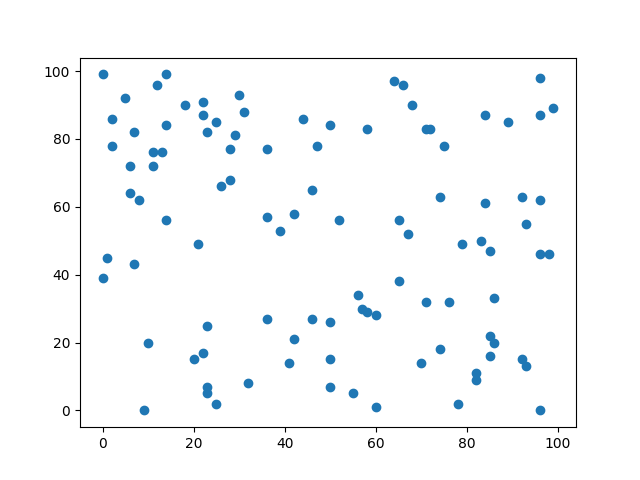

In [10]:
from PIL import Image
import os

img_path = os.path.join(temp_dir.name, "scatter.png")
img = Image.open(img_path)

img

##### 

In [40]:
code_writer_system_message = """
You are code_writer_agent.
Generate FULL Python code in exactly one ```python ... ``` block.
Rules:
- Always produce complete, executable Python code.
- Use print statements for user-facing output.
- For benchmark tasks, print only the required result lines and no extra commentary.
- When asked for timing output, format values with six decimal places.
- If execution feedback contains errors, fix them and return corrected full code.
- Do not use built-in shortcuts like sort(); implement algorithms manually.
- Keep code modular and readable.
""".strip()

In [41]:
groq_api_key = os.getenv("GROQ_API_KEY")
if not groq_api_key:
    raise ValueError("Set GROQ_API_KEY in your environment before running this notebook.")

groq_llm_config = {
    "config_list": [
        {
            "model": "llama-3.3-70b-versatile",
            "api_key": groq_api_key,
            "base_url": "https://api.groq.com/openai/v1",
        },
        {
            "model": "llama-3.1-8b-instant",
            "api_key": groq_api_key,
            "base_url": "https://api.groq.com/openai/v1",
        }
    ],
    "temperature": 0,
}

code_writer_agent = ConversableAgent(
    "code_writer_agent",
    system_message=code_writer_system_message,
    llm_config=groq_llm_config,
    human_input_mode="NEVER",
    is_termination_msg=lambda msg: isinstance(msg, dict) and msg.get("role") == "assistant" and msg.get("content", "").strip().endswith("TERMINATE"),
)

In [47]:
benchmark_task = """
Create a Python program that benchmarks Bubble Sort vs Quick Sort.
Requirements:
1. Generate random integer data.
2. Implement Bubble Sort manually.
3. Implement Quick Sort manually.
4. Measure execution time for both implementations.
5. Print exactly these three lines and nothing else:
   Bubble Sort time: <value> seconds
   Quick Sort time: <value> seconds
   Quick Sort is faster.
6. Use f-strings with six decimal places for the timing values.
7. Also write the same three lines to benchmark_output.txt in the working directory.
8. Keep output clean and readable.
9. Return only one full Python code block.
""".strip()

print("Benchmark task ready.")

Benchmark task ready.


In [48]:
chat_result = code_executor_agent.initiate_chat(
    code_writer_agent,
    message=benchmark_task,
    max_turns=6,
)

print("Autonomous benchmark run completed.")

code_executor_agent (to code_writer_agent):

Create a Python program that benchmarks Bubble Sort vs Quick Sort.
Requirements:
1. Generate random integer data.
2. Implement Bubble Sort manually.
3. Implement Quick Sort manually.
4. Measure execution time for both implementations.
5. Print exactly these three lines and nothing else:
   Bubble Sort time: <value> seconds
   Quick Sort time: <value> seconds
   Quick Sort is faster.
6. Use f-strings with six decimal places for the timing values.
7. Also write the same three lines to benchmark_output.txt in the working directory.
8. Keep output clean and readable.
9. Return only one full Python code block.

--------------------------------------------------------------------------------
[autogen.oai.client: 04-19 21:26:24] {744} WARNING - Model llama-3.3-70b-versatile is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
code_writer_agent (to c

In [49]:
from pathlib import Path
import contextlib
import io

def run_script_without_terminate(script_path):
    source = script_path.read_text(encoding="utf-8", errors="ignore")
    cleaned_source = "\n".join(line for line in source.splitlines() if line.strip() != "TERMINATE")
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):
        exec(compile(cleaned_source, str(script_path), "exec"), {"__name__": "__main__"})
    return buffer.getvalue().strip()

workspace_path = Path(temp_dir.name)
workspace_files = [p.name for p in workspace_path.iterdir()]

print("Files in workspace:")
for name in workspace_files:
    print(f"- {name}")

py_files = [p for p in workspace_path.iterdir() if p.suffix.lower() == ".py"]
if py_files:
    print("\nGenerated Python files and run output:")
    latest_py_file = sorted(py_files, key=lambda path: path.stat().st_mtime, reverse=True)[0]
    print("-" * 72)
    print(f"File: {latest_py_file.name}")
    print(run_script_without_terminate(latest_py_file))
else:
    print("\nNo Python files detected.")

text_outputs = [p for p in workspace_path.iterdir() if p.suffix.lower() in {".txt", ".log", ".json"}]
if text_outputs:
    print("\nSample generated outputs:")
    for p in text_outputs:
        print("-" * 72)
        print(f"File: {p.name}")
        content = p.read_text(encoding="utf-8", errors="ignore")
        print(content)
else:
    print("\nNo text output files detected.")

Files in workspace:
- benchmark_output.txt
- tmp_code_05b836d0d490e6001baa4ee0d01450ae.py
- tmp_code_73e93a458ed92713f06583afb3e9331e.py
- tmp_code_cee089352425900c222917e35ff33bf7.py
- tmp_code_e0d80cac2334eee11a8ed0e1e007b304.py

Generated Python files and run output:
------------------------------------------------------------------------
File: tmp_code_73e93a458ed92713f06583afb3e9331e.py
Bubble Sort time: 0.077107 seconds
Quick Sort time: 0.003613 seconds
Quick Sort is faster.

Sample generated outputs:
------------------------------------------------------------------------
File: benchmark_output.txt
Bubble Sort time: 0.077558 seconds
Quick Sort time: 0.003000 seconds
Quick Sort is faster.

